In [1]:
import os
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import requests
from shapely.geometry import box
import zipfile
import pyarrow as pa
import pyarrow.parquet as pq
import xarray as xr
import xvec
import dask
from dask.distributed import Client

client = Client()
client

/Users/nfs/Documents/Code/2-auspatious/csdr-cloud-spatial/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 4
Total threads: 8,Total memory: 24.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:57001,Workers: 4
Dashboard: http://127.0.0.1:8787/status,Total threads: 8
Started: Just now,Total memory: 24.00 GiB
Comm: tcp://127.0.0.1:57023,Total threads: 2
Dashboard: http://127.0.0.1:57024/status,Memory: 6.00 GiB
Nanny: tcp://127.0.0.1:57004,


In [2]:
gmw_url = "https://zenodo.org/records/12756047/files/gmw_mng_2020_v4019_gtiff.zip?download=1"
gmw_local_zip = "in/gmw_latest.zip"
gmw_local_dir = "in/gmw_latest"

In [ ]:
if not os.path.exists("in/"):
    os.makedirs("in/", exist_ok=True)

if not os.path.exists("out/"):
    os.makedirs("out/", exist_ok=True)

print(f"Downloading Global Mangrove Watch data...")
response = requests.get(gmw_url)

with open(gmw_local_zip, "wb") as f:
    print(f"Writing to {gmw_local_zip}")
    f.write(response.content)

Writing to in/gmw_latest.zip


In [4]:
print(f"Unzipping {gmw_local_zip} to {gmw_local_dir}")
with zipfile.ZipFile(gmw_local_zip, "r") as zip_ref:
    zip_ref.extractall(gmw_local_dir)

Unzipping in/gmw_latest.zip to in/gmw_latest


In [3]:
# Build VRT
print("Building VRT...")

# Call bash
os.system(f"bash -c 'gdalbuildvrt {gmw_local_dir}.vrt {gmw_local_dir}/*.tif'")

Building VRT...
0...10...20...30...40...50...60...70...80...90...100 - done.


0

In [ ]:
# Convert to zarr (WARNING: this will take up to 30 mins)
print("Convert to zarr...")

os.system(f"bash -c 'gdal_translate -co BLOCKSIZE=\'10000,10000\' -of ZARR {gmw_local_dir}.vrt  {gmw_local_dir}.zarr'")

Convert to zarr...
Input file size is 3600000, 740000
0

In [ ]:
# Read in zarr
print("Read in zarr")
gmw = xr.open_zarr(f"{gmw_local_dir}.zarr")

# rename X and y to x and y (otherwise we hit some bug in xvec)
gmw = gmw.rename({"X": "x", "Y": "y"})

gmw

# Do example zonal statistics for small area around Townsville

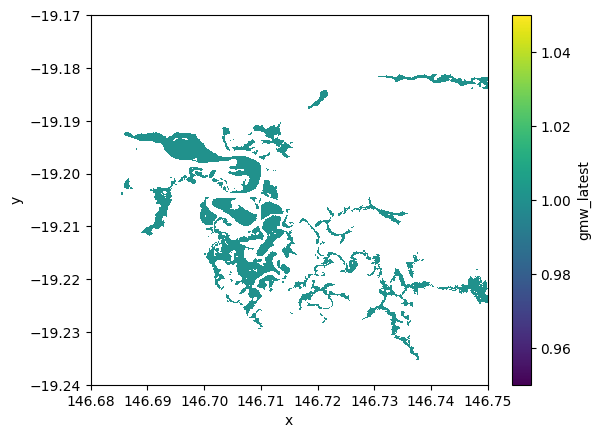

In [112]:
subset = gmw.gmw_latest.sel(x=slice(146.68, 146.75), y=slice(-19.17, -19.24))

subset.plot()

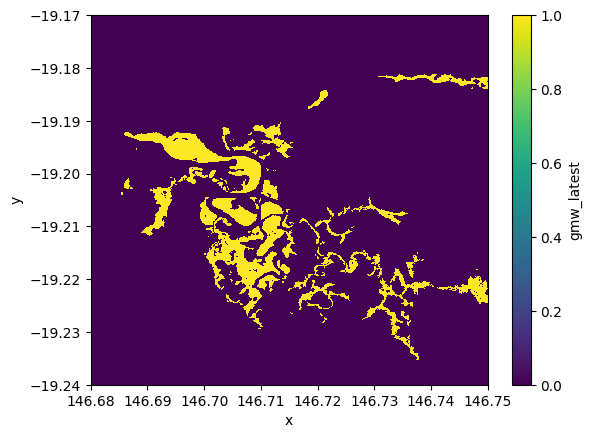

In [113]:
subset = subset.fillna(0)
subset.plot()

In [114]:
print('aggregating')

gdf = gpd.GeoDataFrame(
    geometry=[box(146.7, -19.22, 146.73, -19.20)]
)

# Read in ASGS STE
aggregated_mean = subset.xvec.zonal_stats(
    gdf.geometry,
    x_coords="x",
    y_coords="y",
    stats=["mean", ]
)

aggregating


In [117]:
aggregated_mean.compute()

<xarray.DataArray 'gmw_latest' (geometry: 1, zonal_statistics: 1)> Size: 4B
array([[0.2798]], dtype=float32)
Coordinates:
  * zonal_statistics  (zonal_statistics) <U4 16B 'mean'
  * geometry          (geometry) object 8B POLYGON ((146.73 -19.22, 146.73 -1...
Indexes:
    geometry  GeometryIndex (crs=None)
Attributes:
    COLOR_INTERPRETATION:  Gray
    _CRS:                  {'wkt': 'GEOGCRS["WGS 84",DATUM["World Geodetic Sy...

# Do zonal statistics across all states

In [4]:
abs_asgs_ste_path = "../../geometries/abs-asgs-edition-3/out/ste2021.parquet"

# Read in ASGS STE
asgs_ste_gdf = gpd.read_parquet(abs_asgs_ste_path)

# Filter out rows without geoms
asgs_ste_gdf = asgs_ste_gdf[asgs_ste_gdf.geometry.notnull()]

asgs_ste_gdf

,STE_CODE21,STE_NAME21,CHG_FLAG21,CHG_LBL21,AUS_CODE21,AUS_NAME21,AREASQKM21,LOCI_URI21,geometry
0,1,New South Wales,0,No change,AUS,Australia,8.007977e+05,http://linked.data.gov.au/dataset/asgsed3/STE/1,"MULTIPOLYGON (((159.0623 -31.50886, 159.06218 ..."
1,2,Victoria,0,No change,AUS,Australia,2.274962e+05,http://linked.data.gov.au/dataset/asgsed3/STE/2,"MULTIPOLYGON (((146.29286 -39.15778, 146.29341..."
2,3,Queensland,0,No change,AUS,Australia,1.730171e+06,http://linked.data.gov.au/dataset/asgsed3/STE/3,"MULTIPOLYGON (((142.5314 -10.68301, 142.53072 ..."
3,4,South Australia,0,No change,AUS,Australia,9.842314e+05,http://linked.data.gov.au/dataset/asgsed3/STE/4,"MULTIPOLYGON (((140.66025 -38.06256, 140.66006..."
4,5,Western Australia,0,No change,AUS,Australia,2.526632e+06,http://linked.data.gov.au/dataset/asgsed3/STE/5,"MULTIPOLYGON (((117.86953 -35.19108, 117.86961..."
5,6,Tasmania,0,No change,AUS,Australia,6.801754e+04,http://linked.data.gov.au/dataset/asgsed3/STE/6,"MULTIPOLYGON (((144.60439 -41.01001, 144.60443..."
6,7,Northern Territory,0,No change,AUS,Australia,1.348134e+06,http://linked.data.gov.au/dataset/asgsed3/STE/7,"MULTIPOLYGON (((133.02818 -10.90839, 133.02982..."
7,8,Australian Capital Territory,0,No change,AUS,Australia,2.358133e+03,http://linked.data.gov.au/dataset/asgsed3/STE/8,"POLYGON ((149.06239 -35.1591, 149.09134 -35.14..."
8,9,Other Territories,0,No change,AUS,Australia,2.557420e+02,http://linked.data.gov.au/dataset/asgsed3/STE/9,"MULTIPOLYGON (((167.94747 -29.12757, 167.94748..."


<Axes: >

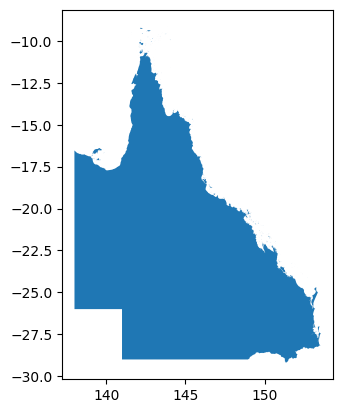

In [5]:
# Plot Queensland
asgs_ste_gdf.iloc[[2]].plot()

In [6]:
gmw.chunks

Frozen({'y': (1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 10

In [ ]:
subset = gmw.gmw_latest.sel(x=slice(asgs_ste_gdf.total_bounds[0], asgs_ste_gdf.total_bounds[2]), y=slice(asgs_ste_gdf.total_bounds[1], asgs_ste_gdf.total_bounds[3])).compute()

In [15]:
aggregated_mean = test.xvec.zonal_stats(
    asgs_ste_gdf.geometry,
    x_coords="x",
    y_coords="y",
    stats=["mean", ]
)

: 